# Compare feature sets across hazel, cernak, and rxnpredict

Combines the three `review_*` notebooks' pooled summaries (`gp_collab_hazel`,
`gp_collab_cernak`, `gp_collab_rxnpredict`) purely for comparison. It re-reads
their existing `runs/*/hazel_export` exports the same way those notebooks do
-- no new fits are launched here.

Two charts:
1. Pooled 5-fold CV (`kfold`) R^2 per feature set, grouped by dataset.
2. Matched IID (`iid_matched`) beside LOLO (`lolo`) per feature set, grouped
   by dataset.

Each dataset's block of bars sits close together with only a slight gap to
the next dataset, and gets its own bracket and label underneath the
feature-set names, which all share one tick angle. Needs `numpy pandas
matplotlib` -- the per-project `gpc/results.py` (byte-identical across all
three) is reused directly, so nothing here needs PyTorch either.

In [38]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from IPython.display import display

ROOT = Path.cwd().resolve()          # this notebook lives at the DOPE-MURI repo root

# One run folder per project, matching the RUNS each project's own review
# notebook currently points at.
PROJECTS = {
    'hazel':      {'dir': ROOT / 'gp_collab_hazel', 'runs': 'runs/pcs_v3',
                   'exclude_models': []},
    'cernak':     {'dir': ROOT / 'gp_collab_cernak', 'runs': 'runs/cernak_v1',
                   'exclude_models': ['cernak_full', 'cernak_full_ohe']},
    'rxnpredict': {'dir': ROOT / 'gp_collab_rxnpredict', 'runs': 'runs/rxnpredict_pcs_v3',
                   'exclude_models': ['rxnpredict_full', 'rxnpredict_full_ohe']},
}

# gpc/results.py has no relative imports and is byte-identical across all
# three projects, so importing it from one project's folder covers all three.
sys.path.insert(0, str(PROJECTS['hazel']['dir']))
from gpc.results import prepare, load_results, method_label, rank_features

tables_by_project = {}
for name, info in PROJECTS.items():
    export = prepare(info['dir'] / info['runs'], bundle=info['dir'] / 'inputs', refresh=False)
    tables, collection = load_results(export)
    tables_by_project[name] = tables
    complete = collection['complete']
    done = collection['completed_tasks']
    expected = collection['expected_tasks']
    print(f'{name}: complete={complete}  {done}/{expected} tasks')

using the existing export at C:\Users\koand\OneDrive\Documents\GitHub\DOPE-MURI\gp_collab_hazel\runs\pcs_v3\hazel_export (refresh=True to rebuild)
hazel: complete=True  105/105 tasks
using the existing export at C:\Users\koand\OneDrive\Documents\GitHub\DOPE-MURI\gp_collab_cernak\runs\cernak_v1\hazel_export (refresh=True to rebuild)
cernak: complete=True  75/75 tasks
using the existing export at C:\Users\koand\OneDrive\Documents\GitHub\DOPE-MURI\gp_collab_rxnpredict\runs\rxnpredict_pcs_v3\hazel_export (refresh=True to rebuild)
rxnpredict: complete=True  90/90 tasks


In [39]:
# Feature sets carry different model keys per project (catalyst_ohe vs
# ligand_ohe) even though they play the same role, so they are relabelled onto
# one shared axis here. Edit this if a project's run adds or renames a set.
FEATURESET_LABELS = {
    'catalyst_ohe': 'OHE', 'ligand_ohe': 'OHE',
    'selected_2': 'Selected-2', 'selected_5': 'Selected-5',
    'pc_top': 'PC top', 'pc_scores': 'PC scores',
}
FEATURESET_ORDER = ['OHE', 'Selected-2', 'Selected-5', 'PC top', 'PC scores']

rows = []
for name, info in PROJECTS.items():
    summary = tables_by_project[name]['summary']
    pooled = summary[summary.aggregation == 'pooled_predictions'].copy()
    pooled = pooled[~pooled.model.isin(info['exclude_models'])]
    pooled['dataset'] = name
    pooled['featureset'] = pooled['model'].map(FEATURESET_LABELS).fillna(pooled['model'])
    rows.append(pooled)
combined = pd.concat(rows, ignore_index=True)

missing = {name: sorted(set(FEATURESET_ORDER) - set(combined.loc[combined.dataset == name, 'featureset']))
           for name in PROJECTS}
missing = {name: fs for name, fs in missing.items() if fs}
if missing:
    print('Missing feature sets (will show as gaps in the charts below):', missing)

display(combined.pivot_table(index=['dataset', 'featureset'], columns='method',
                              values='r2', aggfunc='first')
                 .reindex(FEATURESET_ORDER, level='featureset').round(4))

method                 iid_matched   kfold  kfold_5    lolo
dataset    featureset                                      
cernak     OHE              0.7982  0.7982      NaN  0.6078
           Selected-2       0.7890  0.7890      NaN  0.6527
           Selected-5       0.7887  0.7887      NaN  0.2238
           PC top           0.7894  0.7894      NaN  0.3009
           PC scores        0.7911  0.7911      NaN  0.3830
hazel      OHE              0.9252  0.9231      NaN  0.5401
           Selected-2       0.9239  0.9212      NaN  0.6460
           Selected-5       0.9273  0.9238      NaN  0.5705
           PC top           0.9281  0.9249      NaN  0.6156
           PC scores        0.9245  0.9209      NaN  0.5041
rxnpredict OHE              0.9376  0.9382   0.9377  0.6791
           Selected-2       0.9353  0.9362   0.9345  0.7398
           Selected-5       0.9355  0.9365   0.9347  0.5884
           PC top           0.9371  0.9387   0.9373 -0.0652
           PC scores        0.9349  0.9360   0.9351  0.6413

In [44]:
# x positions for `bars_per_group` bars in each of `n_groups` groups. Bars sit
# edge-to-edge inside a group; groups are separated by group_gap -- the slight
# gap between datasets. Returns (positions, bounds): positions is one array of
# x-coordinates per group, bounds is the (left, right) span of each group, for
# draw_group_brackets below.
def grouped_bar_positions(n_groups, bars_per_group, bar_width=0.8, group_gap=0.9):
    positions, bounds, cursor = [], [], 0.0
    for _ in range(n_groups):
        group = cursor + bar_width * np.arange(bars_per_group)
        positions.append(group)
        bounds.append((group[0] - bar_width / 2, group[-1] + bar_width / 2))
        cursor = group[-1] + bar_width + group_gap
    return positions, bounds


# A square bracket under each (left, right) span in `bounds`, with labels[i]
# centered beneath it -- the per-dataset bracket the feature-set tick labels
# sit inside. y/tick are axes-fraction units while x stays in data units, so
# the bracket sits at a fixed visual depth regardless of the data's own scale.
def draw_group_brackets(ax, bounds, labels, y=-0.20, tick=0.035, fontsize=9):
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for (left, right), label in zip(bounds, labels):
        ax.plot([left, left, right, right], [y + tick, y, y, y + tick],
                 color='0.3', linewidth=0.9, transform=trans, clip_on=False)
        ax.text((left + right) / 2, y - tick * 1.6, label, transform=trans,
                 ha='center', va='top', fontsize=fontsize)


# ax.bar_label anchors each label just past the bar's far tip, which for a
# negative value lands below the x-axis -- off the plot, since the y limit is
# hard-floored at 0 below. This anchors at the value's own height when it is
# >= 0 (unchanged behaviour), and at the zero baseline -- where a positive
# bar's label would sit -- when it is negative, so the number is still shown
# even though the bar itself is clipped at 0.
def label_bars(ax, bars, values, fmt='%.2f', fontsize=7, pad_points=2):
    for bar, value in zip(bars, values):
        if not np.isfinite(value):
            continue
        y = value if value >= 0 else 0.0
        ax.annotate(fmt % value, xy=(bar.get_x() + bar.get_width() / 2, y),
                    xytext=(0, pad_points), textcoords='offset points',
                    ha='center', va='bottom', fontsize=fontsize)


# Hard floor at 0, always -- a negative bar is clipped rather than shifting
# the axes down to show it; label_bars above still reports its value at the
# baseline.
def set_bar_ylim(ax, values, top_margin=1.15):
    hi = max(0.0, float(np.nanmax(values)))
    ax.set_ylim(0, hi * top_margin)


# Same palette gp_collab_hazel/cernak/rxnpredict use for these three methods in
# their own 'Compare the three evaluation methods' chart.
METHOD_COLORS = {'lolo': '#c0392b', 'iid_matched': '#5b8db8', 'kfold': '#a8c8e0'}

# One distinguishable color per feature set (colorblind-safe, Okabe-Ito), used
# by the 5-fold-CV-only chart below, where color encodes featureset rather
# than method.
FEATURESET_COLORS = {
    'OHE': '#E69F00', 'Selected-2': '#0072B2', 'Selected-5': '#009E73',
    'PC top': '#D55E00', 'PC scores': '#CC79A7',
}

# One color per dataset, used by the feature-importance comparison at the end
# where color encodes dataset rather than method or featureset.
DATASET_COLORS = {'hazel': 'tab:blue', 'cernak': 'tab:orange', 'rxnpredict': 'tab:green'}

TICK_ANGLE = 25   # shared x-tick rotation for both charts below

### 5-fold CV by feature set

One bar per feature set, each in its own color (`FEATURESET_COLORS`) so the
five feature sets stay easy to tell apart across datasets. `DATASET_NAMES`,
`TITLE`, and `YLABEL` above the chart are editable.

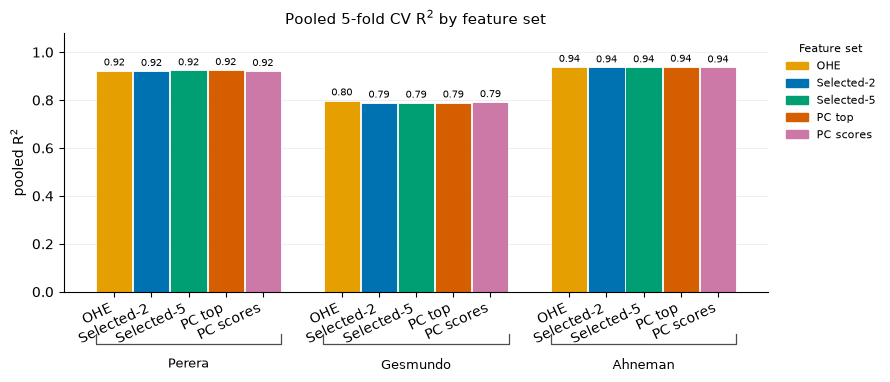

In [45]:
# ---- Editable ----
DATASET_NAMES = {'hazel': 'Perera', 'cernak': 'Gesmundo', 'rxnpredict': 'Ahneman'}
TITLE = 'Pooled 5-fold CV R$^2$ by feature set'
YLABEL = 'pooled R$^2$'
# -------------------

METRIC = 'r2'
METHOD = 'kfold'

plt.close('all')

datasets = list(DATASET_NAMES)
positions, bounds = grouped_bar_positions(len(datasets), len(FEATURESET_ORDER),
                                          bar_width=0.8, group_gap=0.9)
bar_colors = [FEATURESET_COLORS[fs] for fs in FEATURESET_ORDER]

fig, ax = plt.subplots(figsize=(9, 4.5))
values_by_dataset = {}
for group_pos, dataset in zip(positions, datasets):
    part = combined[(combined.dataset == dataset) & (combined.method == METHOD)]
    values = part.set_index('featureset').reindex(FEATURESET_ORDER)[METRIC].to_numpy()
    values_by_dataset[dataset] = values
    bars = ax.bar(group_pos, values, width=0.78, edgecolor='white', linewidth=0.6,
                   color=bar_colors)
    label_bars(ax, bars, values, fontsize=7)

ax.set_xticks(np.concatenate(positions))
ax.set_xticklabels(FEATURESET_ORDER * len(datasets), rotation=TICK_ANGLE, ha='right')
draw_group_brackets(ax, bounds, [DATASET_NAMES[d] for d in datasets])

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=FEATURESET_COLORS[fs]) for fs in FEATURESET_ORDER]
ax.legend(legend_handles, FEATURESET_ORDER, title='Feature set', fontsize=8, title_fontsize=8,
          frameon=False, loc='upper left', bbox_to_anchor=(1.01, 1.0))

ax.set(xlabel='', ylabel=YLABEL)
ax.set_title(TITLE, fontsize=11)
set_bar_ylim(ax, np.concatenate(list(values_by_dataset.values())))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.subplots_adjust(bottom=0.34)

display(fig)
plt.close(fig)

### Matched IID vs LOLO by feature set

Each feature set gets two bars -- `iid_matched` and `lolo` -- in the same two
colors the per-project reviews use for them. `DATASET_NAMES2`, `TITLE2`, and
`YLABEL2` above the chart are editable.

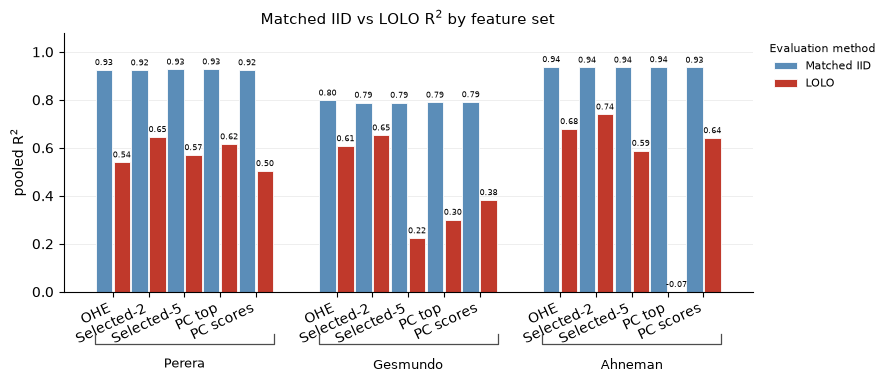

In [46]:
# ---- Editable ----
DATASET_NAMES2 = {'hazel': 'Perera', 'cernak': 'Gesmundo', 'rxnpredict': 'Ahneman'}
TITLE2 = 'Matched IID vs LOLO R$^2$ by feature set'
YLABEL2 = 'pooled R$^2$'
# --------------------

METRIC2 = 'r2'
METHODS2 = ['iid_matched', 'lolo']      # draw order = legend order

plt.close('all')

datasets2 = list(DATASET_NAMES2)
bar_width = 0.36
pair_width = bar_width * len(METHODS2)
positions2, bounds2 = grouped_bar_positions(len(datasets2), len(FEATURESET_ORDER),
                                            bar_width=pair_width, group_gap=0.9)

fig, ax = plt.subplots(figsize=(9, 4.5))
all_values2 = []
for i, method in enumerate(METHODS2):
    xs, heights = [], []
    for group_pos, dataset in zip(positions2, datasets2):
        part = combined[(combined.dataset == dataset) & (combined.method == method)]
        values = part.set_index('featureset').reindex(FEATURESET_ORDER)[METRIC2].to_numpy()
        xs.append(group_pos - pair_width / 2 + bar_width * (i + 0.5))
        heights.append(values)
    xs, heights = np.concatenate(xs), np.concatenate(heights)
    all_values2.append(heights)
    bars = ax.bar(xs, heights, width=bar_width * 0.92, edgecolor='white', linewidth=0.6,
                   color=METHOD_COLORS[method], label=method_label(method))
    label_bars(ax, bars, heights, fontsize=6)

ax.set_xticks(np.concatenate(positions2))
ax.set_xticklabels(FEATURESET_ORDER * len(datasets2), rotation=TICK_ANGLE, ha='right')
draw_group_brackets(ax, bounds2, [DATASET_NAMES2[d] for d in datasets2])

ax.set(xlabel='', ylabel=YLABEL2)
ax.set_title(TITLE2, fontsize=11)
set_bar_ylim(ax, np.concatenate(all_values2))
ax.legend(title='Evaluation method', fontsize=8, title_fontsize=8, frameon=False,
          loc='upper left', bbox_to_anchor=(1.01, 1.0))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
fig.tight_layout()
fig.subplots_adjust(bottom=0.34)

display(fig)
plt.close(fig)

### Feature importance (ARD), by feature set across datasets

One panel per feature set, one color per dataset, sharing a feature axis so
rank and bar length can be read against each other directly. `selected_2`,
`selected_5`, and `pc_scores` use the exact same descriptor/PC names in every
project (`vbur_pct_boltz`, `vbur_pct_min`, ... and `PC1`..`PC4`), so their
bars line up feature-for-feature. `PC top` and `OHE` do not -- pc_top is each
project's own top-loaded descriptors and OHE is each project's own
catalyst/ligand identities -- so a missing bar there means that dataset does
not carry that particular feature at all, not that it scored zero; that gap
is itself part of reading how stable the ranking is.

Needs runs fitted with ard: true under gp in the run config; a feature set
with none available is reported and skipped rather than plotted. `TOP_N`,
`IMPORTANCE_METHOD`, and `IMPORTANCE_FEATURESETS` above the loop are
editable, and dataset display names follow `DATASET_NAMES` from the first
chart.

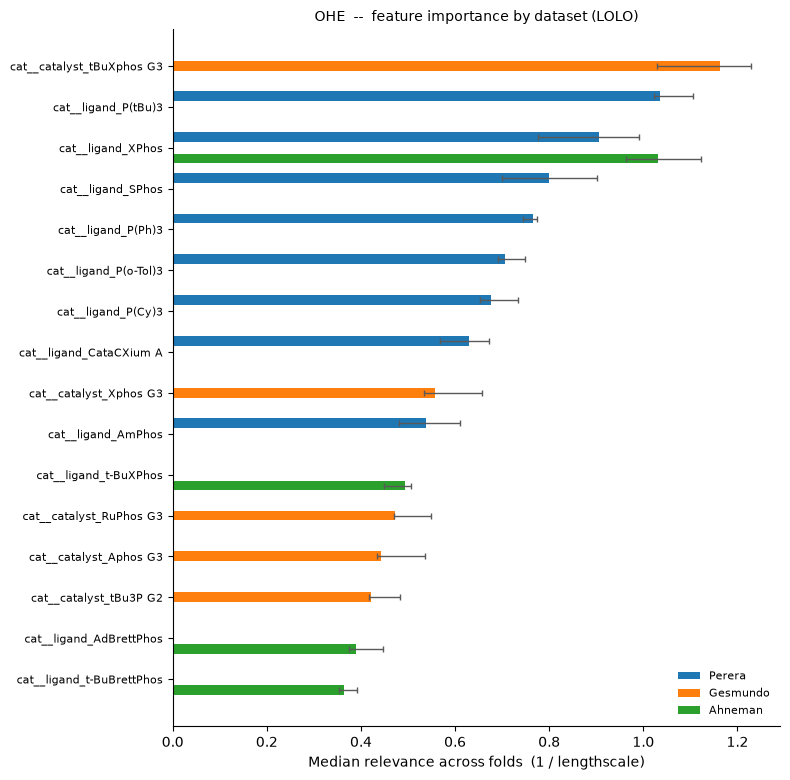

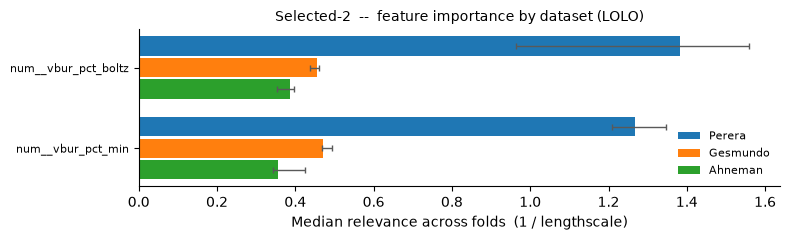

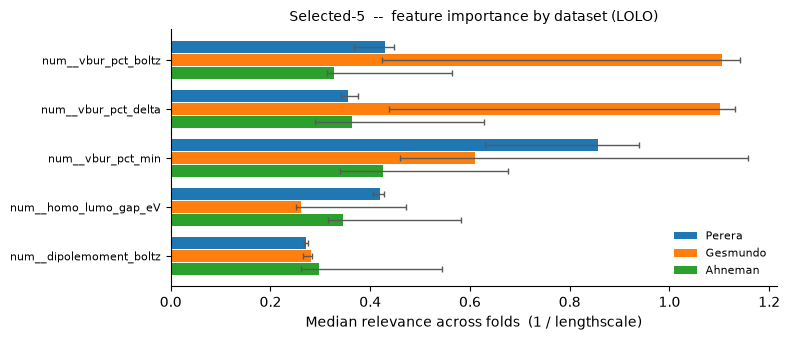

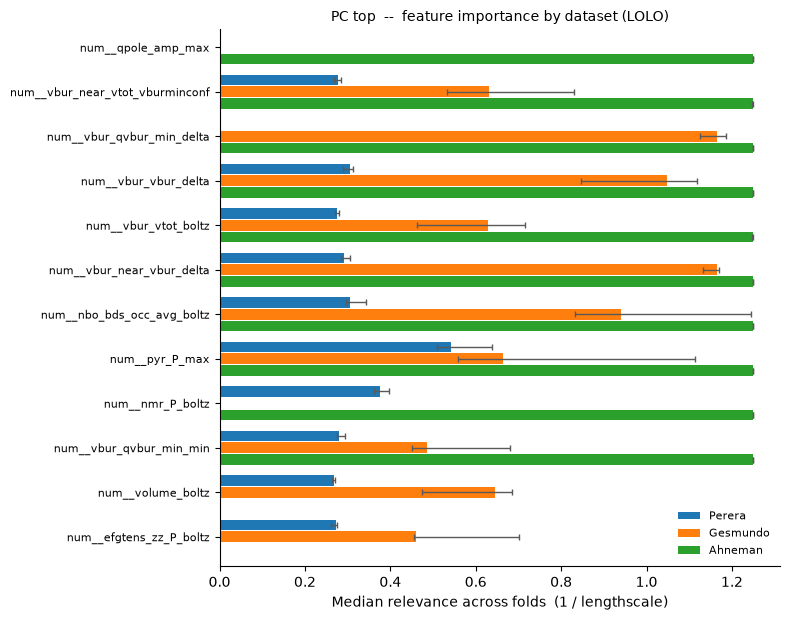

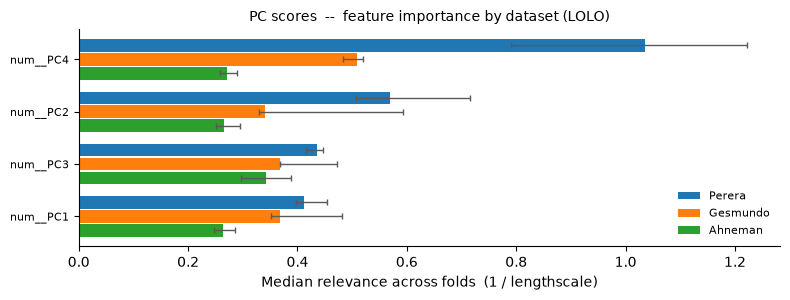

In [47]:
import importlib

# rank_features (imported once, from hazel, in the Load cell) inline-imports
# gpc.data and gpc.features when it actually runs -- and Python resolves those
# against whichever 'gpc' package is currently cached in sys.modules. results.py
# is byte-identical across all three projects, but gpc.data/gpc.features are
# not: they carry each project's own schema (target column name, ligand vs
# catalyst columns, ...). Reusing the cached hazel copy against cernak's or
# rxnpredict's bundle is exactly what raised
# `KeyError: 'Product_Yield_PCT_Area_UV'` -- hazel's gpc.data looked for its own
# target column in another project's reaction table. This swaps in the correct
# project's gpc fresh before each call.
_active_gpc_dir = None

def gpc_results_for(project_dir):
    global _active_gpc_dir
    project_dir = str(project_dir)
    if project_dir != _active_gpc_dir:
        for module_name in list(sys.modules):
            if module_name == 'gpc' or module_name.startswith('gpc.'):
                del sys.modules[module_name]
        if _active_gpc_dir in sys.path:
            sys.path.remove(_active_gpc_dir)
        sys.path.insert(0, project_dir)
        _active_gpc_dir = project_dir
    return importlib.import_module('gpc.results')


# results.py's own `_ligand_columns` (what `ligand_only=True` filters through)
# hardcodes the prefix 'cat__ligand_', because it was written for hazel and
# copied byte-identical into cernak and rxnpredict rather than adapted. Cernak's
# identity column is 'catalyst', not 'ligand' (gpc.config.GROUP = 'catalyst'
# there), so its one-hots are named 'cat__catalyst_...' and `ligand_only=True`
# quietly finds none of them -- raising 'encodes no ligand-block columns to
# rank' for catalyst_ohe specifically, which is what actually produced the 'OHE:
# no ARD lengthscales for [cernak]' message: not a missing ARD run, a hardcoded
# name. This reads each project's own GROUP and filters by *its* prefix instead.
def identity_column_prefix():
    return 'cat__' + importlib.import_module('gpc.config').GROUP + '_'


# ---- Editable ----
TOP_N = 10                       # top features per dataset kept for each feature set
IMPORTANCE_METHOD = 'lolo'
IMPORTANCE_FEATURESETS = FEATURESET_ORDER   # which feature sets to draw a panel for
# -------------------

plt.close('all')

for featureset in IMPORTANCE_FEATURESETS:
    parts, unavailable = [], []
    for name, info in PROJECTS.items():
        model_rows = combined.loc[(combined.dataset == name) & (combined.featureset == featureset), 'model']
        if model_rows.empty:
            continue
        model_key = model_rows.iloc[0]
        project_results = gpc_results_for(info['dir'])
        try:
            if featureset == 'OHE':
                # No numeric columns to fall back on here, and the family tag
                # ligand_only relies on is the thing that is wrong for cernak,
                # so rank everything and filter by this project's own identity
                # prefix instead of trusting 'family'.
                prefix = identity_column_prefix()
                ranked = project_results.rank_features(info['dir'] / info['runs'], info['dir'] / 'inputs',
                                                        model_key, method=IMPORTANCE_METHOD,
                                                        ligand_only=False, top=None)
                ranked = (ranked[ranked.feature.str.startswith(prefix)]
                         .sort_values('median_relevance', ascending=False)
                         .head(TOP_N).reset_index(drop=True))
                if ranked.empty:
                    raise ValueError(f'no columns starting with {prefix!r} among the ranked features')
            else:
                ranked = project_results.rank_features(info['dir'] / info['runs'], info['dir'] / 'inputs',
                                                        model_key, method=IMPORTANCE_METHOD,
                                                        ligand_only=True, top=TOP_N)
        except (ValueError, FileNotFoundError):
            unavailable.append(name)
            continue
        parts.append(ranked.assign(dataset=name))

    if not parts:
        print(f'{featureset}: no ARD lengthscales available for any dataset')
        continue

    table = pd.concat(parts, ignore_index=True)
    # Features ordered by the best rank they reach in any single dataset, so a
    # feature that is top-ranked somewhere floats to the top even where another
    # dataset does not carry it at all -- a missing bar there is itself part of
    # the answer to whether the ranking is stable.
    feature_order = (table.groupby('feature')['median_relevance'].max()
                     .sort_values(ascending=False).index.tolist())
    y_index = {feature: i for i, feature in enumerate(feature_order)}

    datasets_present = list(dict.fromkeys(table.dataset))
    bar_height = 0.8 / len(datasets_present)

    fig, ax = plt.subplots(figsize=(8, max(2.5, 0.4 * len(feature_order) + 1.5)))
    for i, name in enumerate(datasets_present):
        part = table[table.dataset == name]
        y = (np.array([y_index[f] for f in part.feature])
             + (i - (len(datasets_present) - 1) / 2) * bar_height)
        error = np.vstack([(part.median_relevance - part.relevance_q1).to_numpy(),
                           (part.relevance_q3 - part.median_relevance).to_numpy()])
        ax.barh(y, part.median_relevance.to_numpy(), height=bar_height * 0.9, xerr=error,
                color=DATASET_COLORS.get(name, 'tab:gray'),
                error_kw={'ecolor': '0.35', 'elinewidth': 1, 'capsize': 2},
                label=DATASET_NAMES.get(name, name))

    ax.set_yticks(range(len(feature_order)))
    ax.set_yticklabels(feature_order, fontsize=8)
    ax.invert_yaxis()
    ax.set(xlabel='Median relevance across folds  (1 / lengthscale)')
    ax.set_title(f'{featureset}  --  feature importance by dataset ({method_label(IMPORTANCE_METHOD)})',
                fontsize=10)
    ax.legend(fontsize=8, frameon=False, loc='lower right')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()

    display(fig)
    plt.close(fig)
    if unavailable:
        print(f'{featureset}: no ARD lengthscales for', unavailable)